In [1]:
import os

files = os.listdir("Downloads")
for file in files:
    if file.endswith(".csv"):
        print(file)

vacant_posts_2026-02-07.csv


In [2]:
import os

files = os.listdir("Downloads")
for file in files:
    if file.endswith(".csv"):
        print(file)

vacant_posts_2026-02-07.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Downloads/task2/store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [6]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
5,1005,M,33.0,36.7,73.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
8,1008,F,31.0,42.3,43.0
9,1009,M,39.0,48.6,61.0


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [9]:
df.duplicated().sum()

0

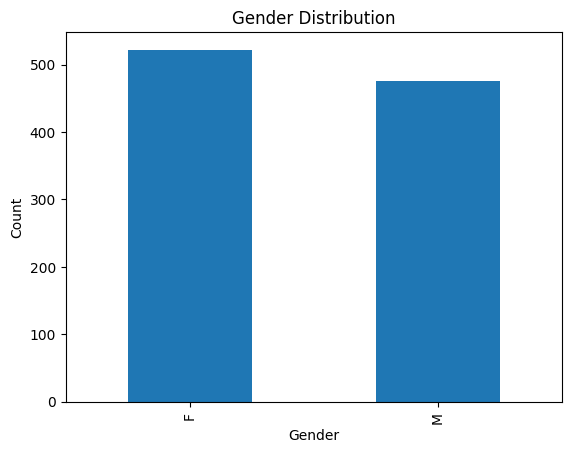

In [10]:
import matplotlib.pyplot as plt

df['Gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

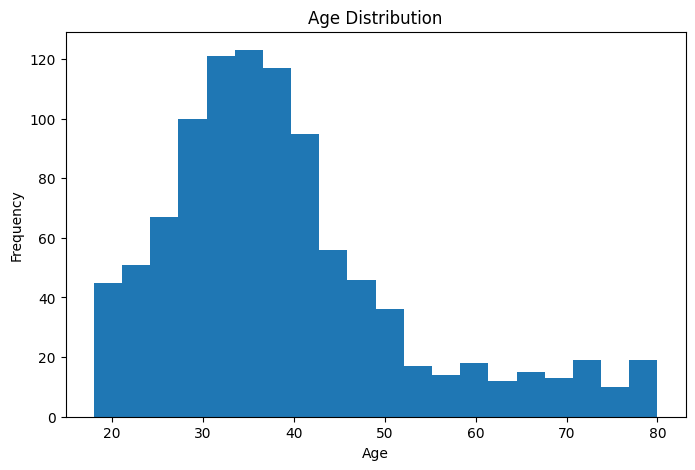

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

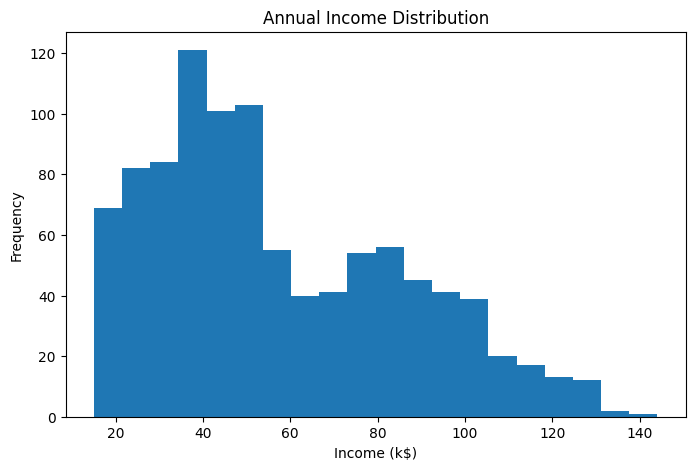

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['Annual Income (k$)'], bins=20)

plt.title("Annual Income Distribution")
plt.xlabel("Income (k$)")
plt.ylabel("Frequency")
plt.show()

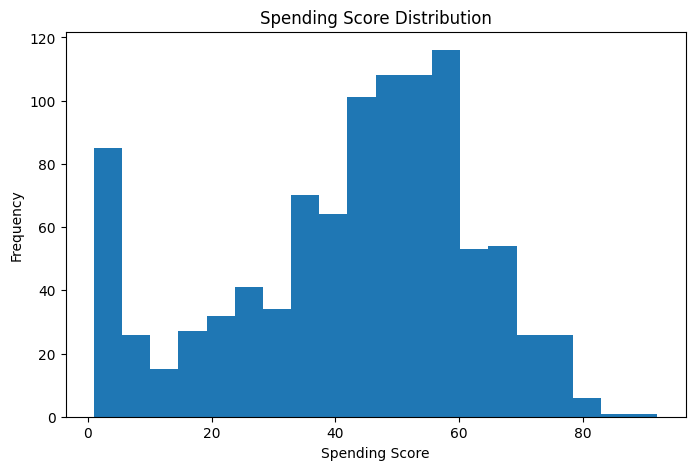

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df['Spending Score (1-100)'], bins=20)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")
plt.show()

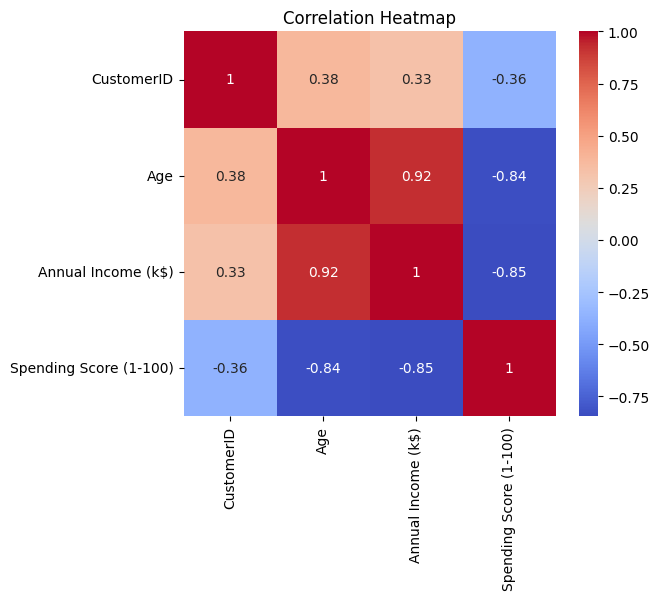

In [14]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [16]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [18]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [19]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [21]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [22]:
df = df.dropna()

In [23]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [24]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [25]:
X.isnull().sum()

Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [26]:
X.isnull().sum()

Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

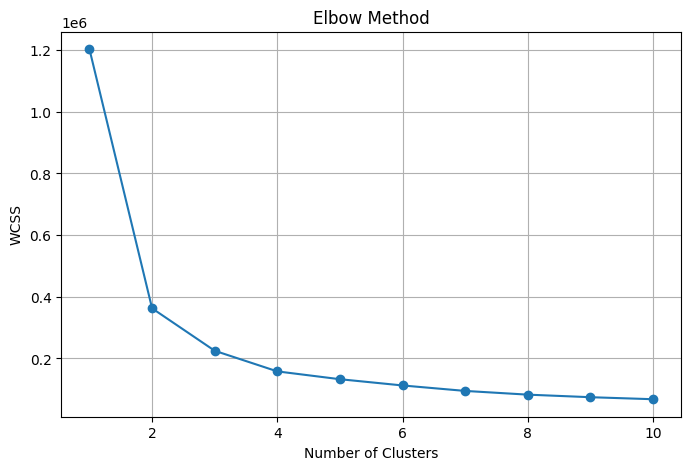

In [28]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [29]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,0
1,1001,M,34.0,48.4,37.0,0
2,1002,F,40.0,70.5,26.0,1
3,1003,F,47.0,81.1,30.0,1
4,1004,F,33.0,42.1,58.0,3


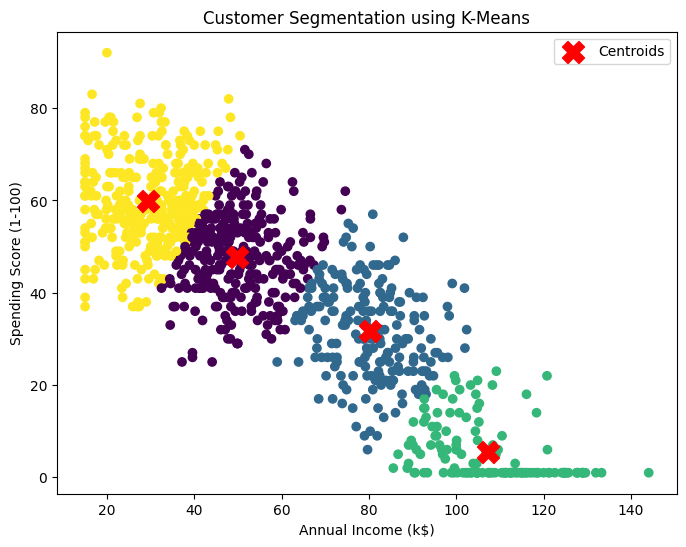

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [31]:
df['Cluster'].value_counts()

Cluster
3    334
0    304
1    208
2    136
Name: count, dtype: int64

In [32]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean()

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,49.841447,47.746711,35.269737
1,80.291346,31.711538,44.798077
2,107.396324,5.588235,65.345588
3,29.450898,59.778443,27.934132


In [ ]:
## Business Insights

- Customer segmentation helps understand purchasing behavior.
- High-income and high-spending customers are the most valuable.
- High-income but low-spending customers can be targeted with personalized promotions.
- Low-income but high-spending customers respond well to discounts and loyalty rewards.
- Budget-friendly campaigns can increase engagement among low-income and low-spending customers.

## Recommendations

- Launch VIP programs for premium customers.
- Use targeted marketing campaigns for each customer segment.
- Provide discounts and loyalty rewards to increase customer retention.
- Personalize product recommendations based on customer behavior.